# DFS 深度优先搜索
## 【零】 引入

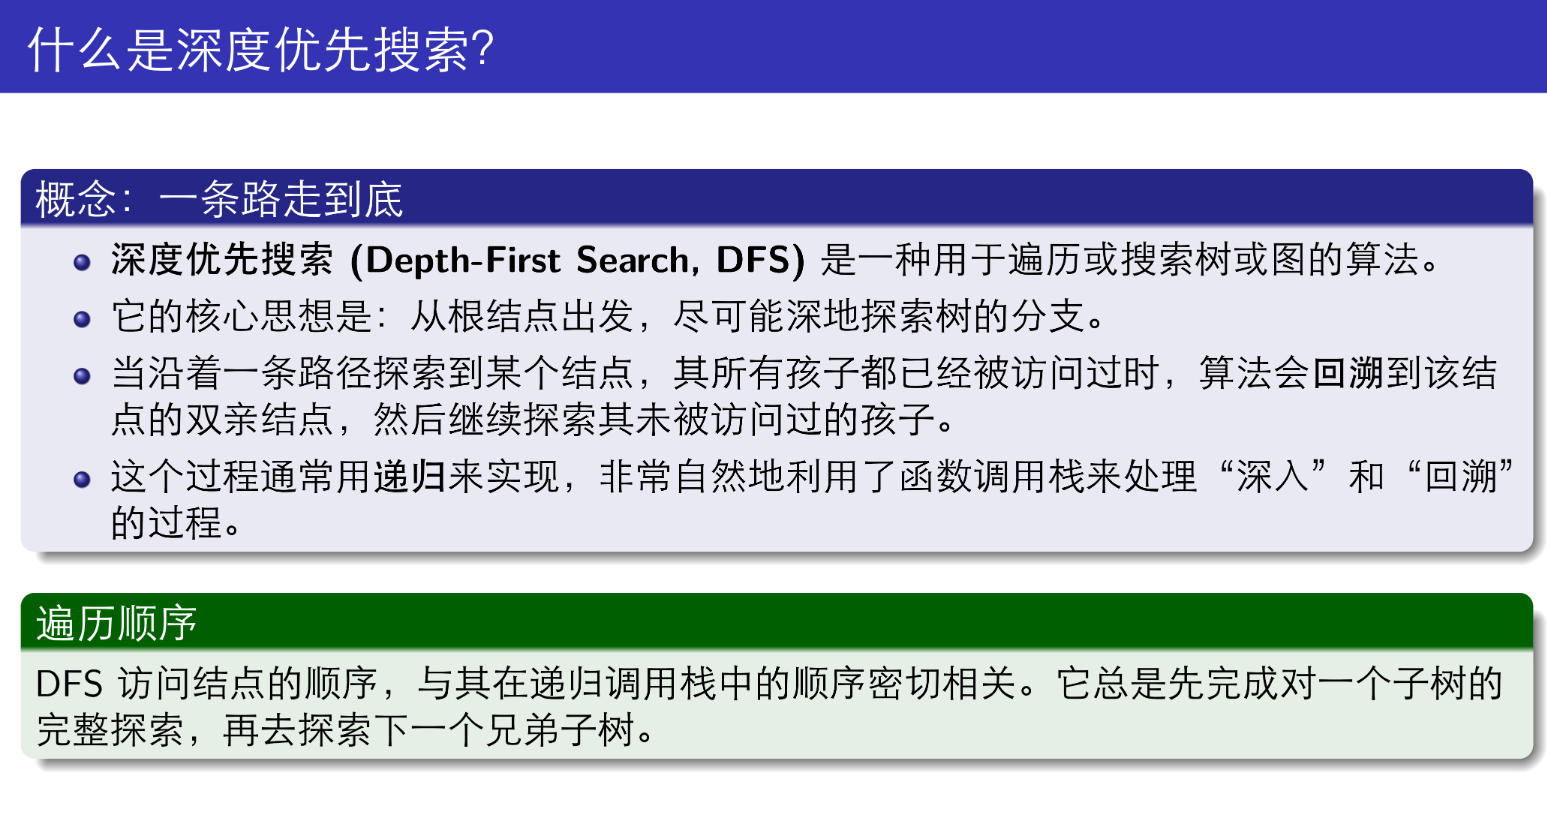
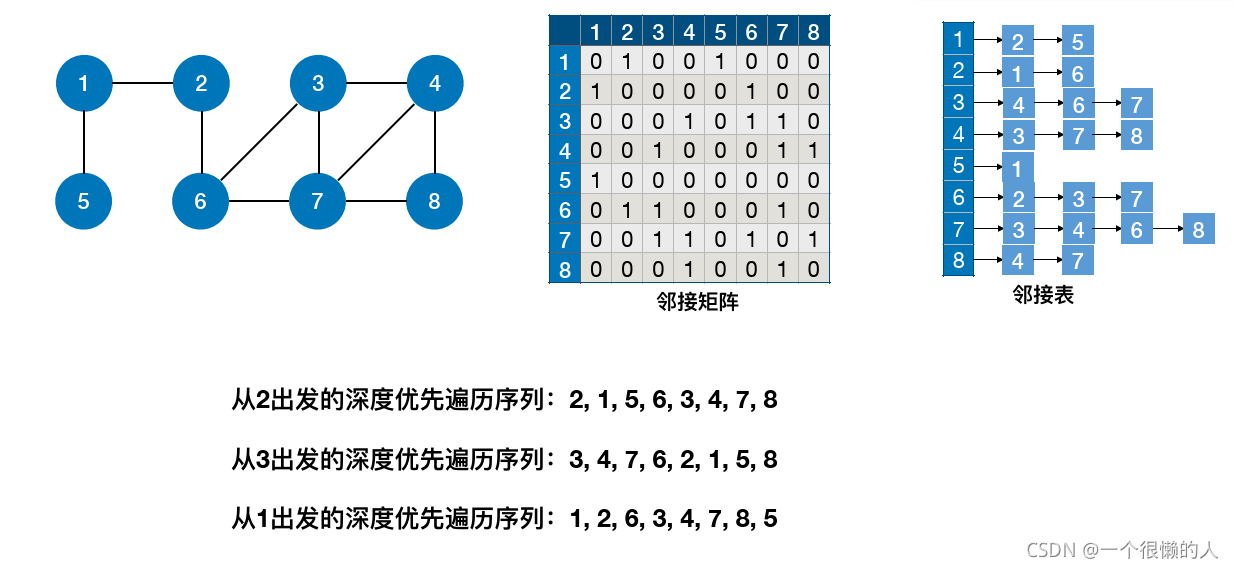
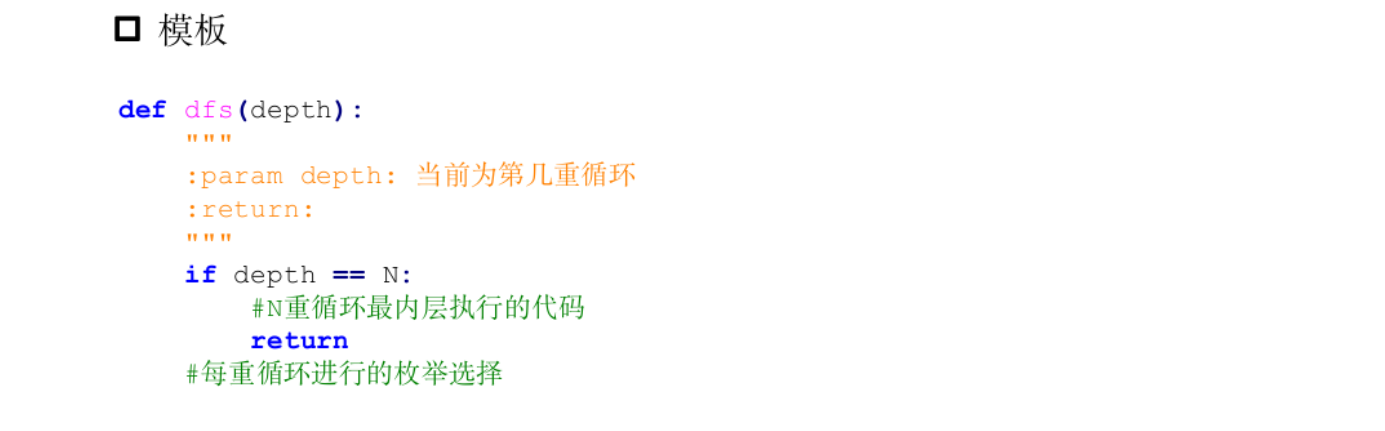
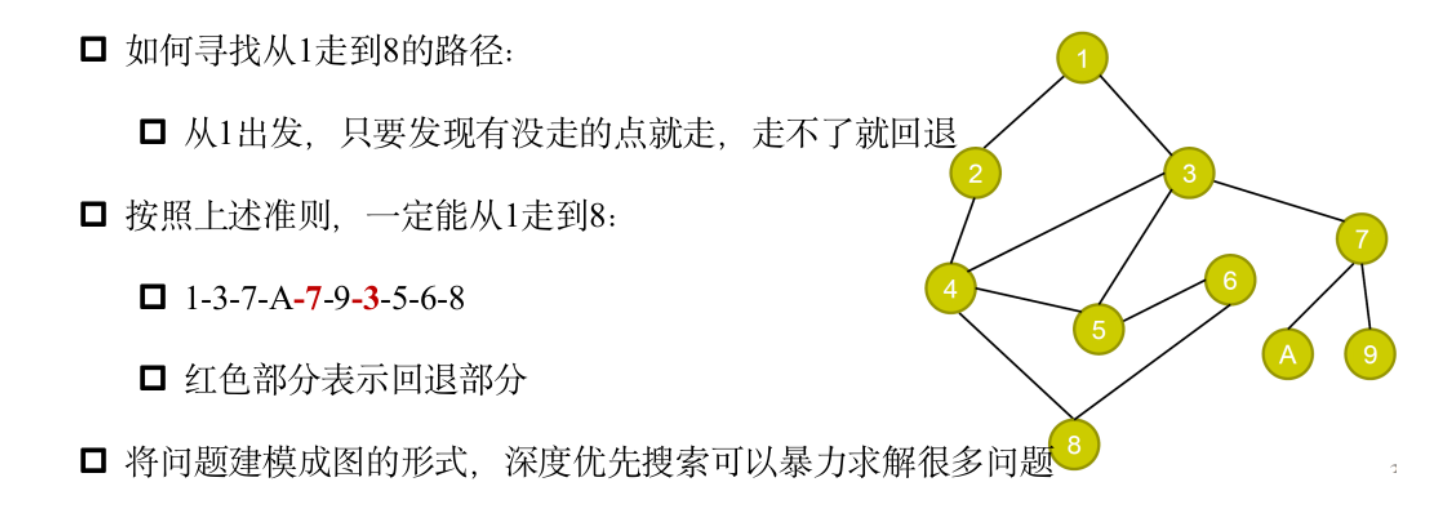
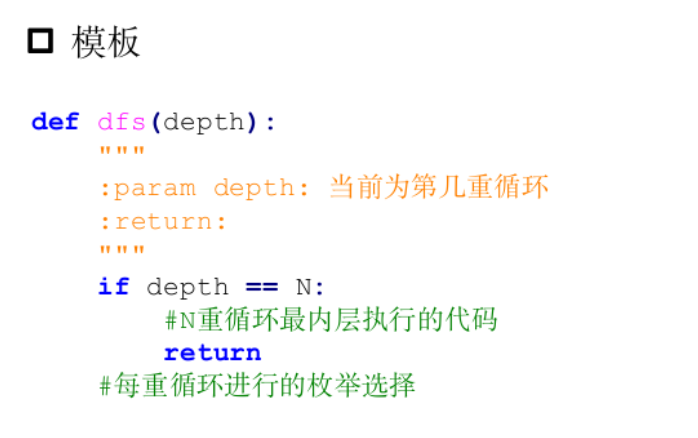
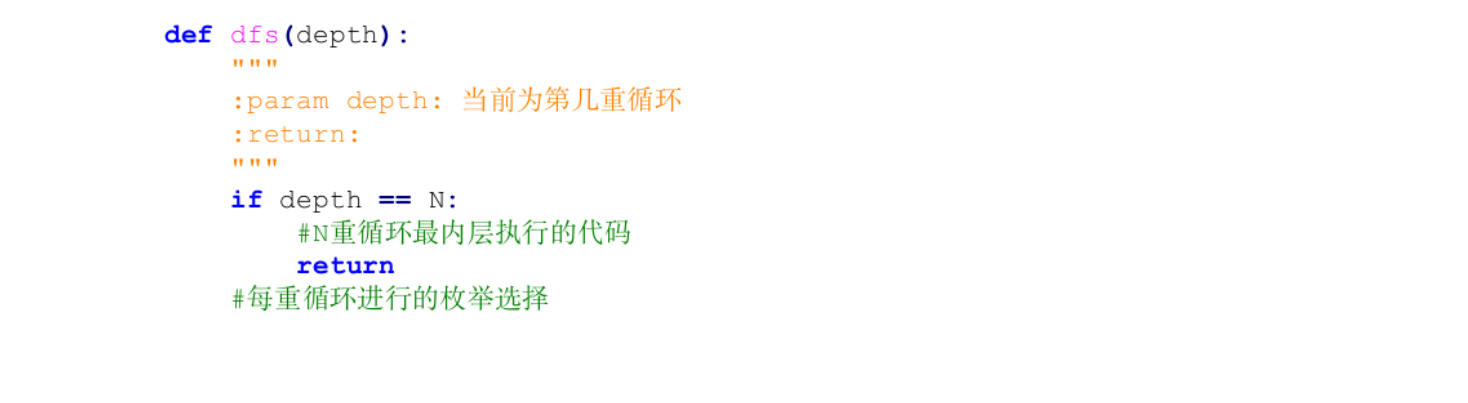
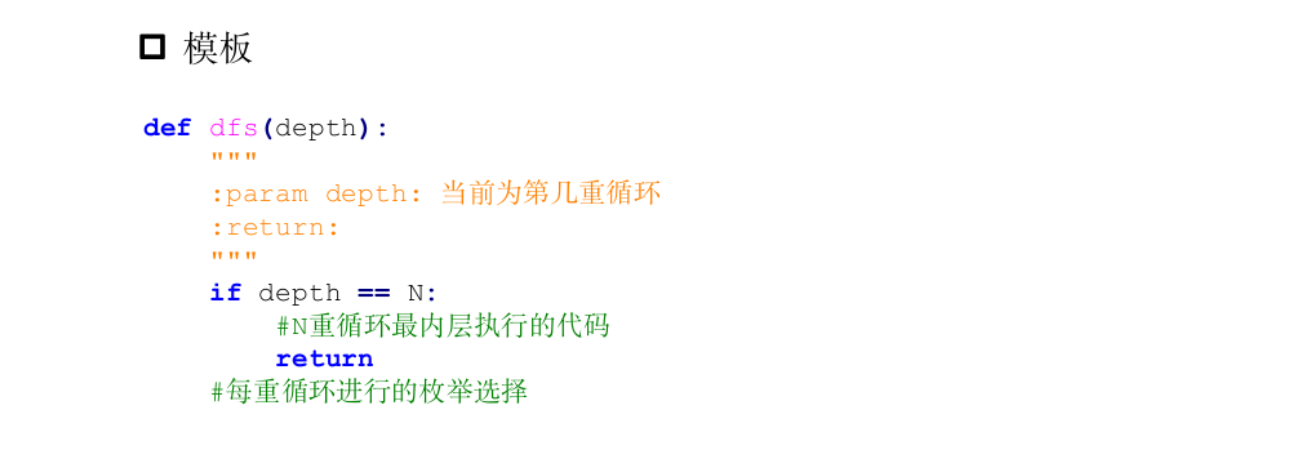
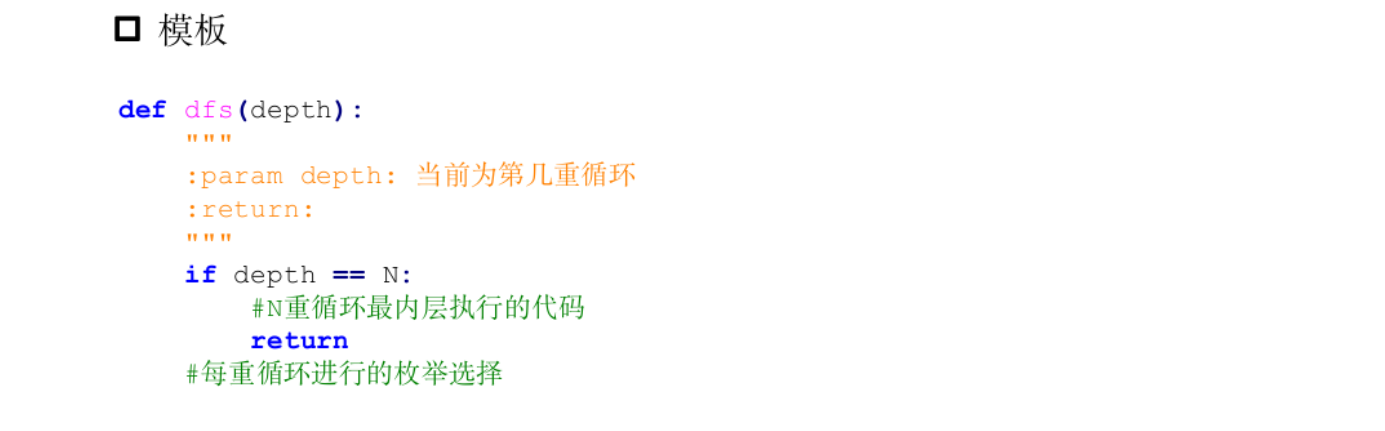

## 【一】 数字拆分

将数字x拆分成n个正整数，要求前一个大于后一个，给出方案

In [13]:
# 原始
x, n = map(int, input().split())

# 记录每层选择数字
a = [0] * n
# 计算次数: cnt
cnt = 0

def dfs(depth):
    """
    :param depth: 当前为第几重循环
    :return:
    """
    global cnt
    cnt = cnt + 1
    # 第0重 - 第n-1重都已经选好数字, 此时只需要判断答案
    if depth == n:
        # 条件一: 数字需要递增
        for i in range(1, n):
            if a[i] >= a[i - 1]:
                continue
            else:
                return
        # 条件二: 数字和为x
        if sum(a) != x:
            return
        # 此时是答案
        print(a)
        return
    # 第depth层进行选择数字: [1,x]进行枚举
    for i in range(1, x + 1):
        # 选择第depth层的数字
        a[depth] = i
        # 递归进入下一层
        dfs(depth + 1)

dfs(0)
print("累计计算次数={}".format(cnt))

[1, 1, 4]
[1, 2, 3]
[2, 2, 2]
累计计算次数=259


In [4]:
# 剪枝
x, n = map(int, input().split())

# 记录每层选择的数字
a = [0] * n
# 累计计算次数
cnt = 0

def dfs(depth, last_val):
    """
    :param depth: 当前为第几重循环
    :param last_val: 上一层选的值，用于保证递增
    :return:
    """
    global cnt
    cnt = cnt + 1

    # 第0重 - 第n-1重都已经选好数字，此时只需要判断答案
    if depth == n:
        # 条件二：数字和为x
        if sum(a) != x:
            return
        # 此时是答案
        print(a)
        return

    # 第depth层进行选择数字: [1, x] 进行枚举
    # 条件一：数字需要递增，因此从last_val开始枚举
    for i in range(last_val, x + 1):
        # 选择第depth层的数字
        a[depth] = i
        # 递归进入下一层，下一层的起始值为当前i，保证递增
        dfs(depth + 1, i)

dfs(0, 1)
print("剪枝后，累计计算次数={}".format(cnt))

[1, 1, 4]
[1, 2, 3]
[2, 2, 2]
剪枝后，累计计算次数=84


由此我们知道，

1、DFS的本质就是n重暴力循环，此时我们理解为树状结构，下面的例子会有更直观的体现

2、剪枝操作可以降低时间复杂度，代价只需要多传一个参数

### leetcode 78 子集
给你一个整数数组 nums，数组中的元素 互不相同。返回该数组所有可能的子集（幂集）。
解集 不能 包含重复的子集。你可以按 任意顺序 返回解集。

示例 1：

输入：nums = [1,2,3]

输出：[[],[1],[2],[1,2],[3],[1,3],[2,3],[1,2,3]]

示例 2：

输入：nums = [0]

输出：[[],[0]]

In [2]:
nums = list(map(int,input().split()))
res = []
n = len(nums)
def dfs(start,tmp):
    res.append(tmp)
    for i in range(start,n):
        dfs(i+1,tmp+[nums[i]])
dfs(0,[])
print(res)

[[], [1], [1, 2], [1, 2, 3], [1, 3], [2], [2, 3], [3]]


In [12]:
# 法二：回溯
nums = list(map(int,input().split()))
n=len(nums)
path=[]
def dfs(depth):
    if depth==n:
        print(path)
        return
    # 选当前这个数字
    path.append(nums[depth])
    dfs(depth+1)
    path.pop()
    #不选当前这个数字
    dfs(depth+1)
dfs(0)

[1, 2, 3]
[1, 2]
[1, 3]
[1]
[2, 3]
[2]
[3]
[]


### leetcode 46 全排列

给定一个不含重复数字的数组 nums ，返回其 所有可能的全排列 。你可以 按任意顺序 返回答案。

示例 1：

输入：nums = [1,2,3]

输出：[[1,2,3],[1,3,2],[2,1,3],[2,3,1],[3,1,2],[3,2,1]]

示例 2：

输入：nums = [0,1]

输出：[[0,1],[1,0]]

In [9]:
# 全排列问题不同于子集问题，必须写回溯
nums = list(map(int,input().split()))
res = []
n = len(nums)
path = []
vis = [False] * n

def dfs(depth):
    if depth == n:
        # 有时候直接print(path)也可以，看输出要求来
        res.append(path.copy())
        return
    for i in range(n):
        if not vis[i]:
            vis[i] = True
            path.append(nums[i])
            dfs(depth+1)
            path.pop()
            vis[i] = False

dfs(0)
print(res)

[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]


### P2404 自然数的拆分问题

#### 题目描述

任何一个大于 $1$ 的自然数 $n$，总可以拆分成若干个小于 $n$ 的自然数之和。现在给你一个自然数 $n$，要求你求出 $n$ 的拆分成一些数字的和。每个拆分后的序列中的数字从小到大排序。然后你需要输出这些序列，其中字典序小的序列需要优先输出。

#### 输入格式

输入：待拆分的自然数 $n$。

#### 输出格式

输出：若干数的加法式子。

#### 输入输出样例 #1

#### 输入 #1

```
7

```

#### 输出 #1

```
1+1+1+1+1+1+1
1+1+1+1+1+2
1+1+1+1+3
1+1+1+2+2
1+1+1+4
1+1+2+3
1+1+5
1+2+2+2
1+2+4
1+3+3
1+6
2+2+3
2+5
3+4
```

#### 说明/提示

数据保证，$2\leq n\le 8$。

In [2]:
n = int(input())
path = []
res = []
def dfs(x,start):
    if x==0:
        print("+".join(map(str,res)))
        return
    for i in range(start,x+1):
        if i==n:
            continue
        res.append(i)
        dfs(x-i,i)
        res.pop()
dfs(n,1)

1+1+1+1+1
1+1+1+2
1+1+3
1+2+2
1+4
2+3


## 【二】 N皇后

### P1219 [USACO1.5] 八皇后 Checker Challenge

#### 题目描述

一个如下的 $6 \times 6$ 的跳棋棋盘，有六个棋子被放置在棋盘上，使得每行、每列有且只有一个，每条对角线（包括两条主对角线的所有平行线）上至多有一个棋子。

![](https://cdn.luogu.com.cn/upload/image_hosting/3h71x0yf.png)

上面的布局可以用序列 $2\ 4\ 6\ 1\ 3\ 5$ 来描述，第 $i$ 个数字表示在第 $i$ 行的相应位置有一个棋子，如下：

行号 $1\ 2\ 3\ 4\ 5\ 6$

列号 $2\ 4\ 6\ 1\ 3\ 5$

这只是棋子放置的一个解。请编一个程序找出所有棋子放置的解。
并把它们以上面的序列方法输出，解按字典顺序排列。
请输出前 $3$ 个解。最后一行是解的总个数。

#### 输入格式

一行一个正整数 $n$，表示棋盘是 $n \times n$ 大小的。

#### 输出格式

前三行为前三个解，每个解的两个数字之间用一个空格隔开。第四行只有一个数字，表示解的总数。

#### 输入输出样例 #1

#### 输入 #1

```
6

```

#### 输出 #1

```
2 4 6 1 3 5
3 6 2 5 1 4
4 1 5 2 6 3
4

```

#### 说明/提示

【数据范围】
对于 $100\%$ 的数据，$6 \le n \le 13$。

题目翻译来自NOCOW。

USACO Training Section 1.5

In [1]:
n = int(input())
vis1 = [False]*(n+1)
vis2 = [False]*(2*n+1)
vis3 = [False]*(2*n+1)

def print1(lis):
    s = " ".join(str(i) for i in lis)
    print(s)

def dfs(depth):
    global ans
    global sol
    global path
    if depth==n+1:
        ans += 1
        sol.append(path.copy())
        if ans == 3:
            return
        return
    for i in range(1,n+1):
        if vis1[i] or vis2[depth+i] or vis3[depth-i+n]:
            continue
        path.append(i)
        vis1[i] = True
        vis2[depth+i] = True
        vis3[depth-i+n] = True
        dfs(depth+1)
        path.pop()
        vis1[i] = False
        vis2[depth+i] = False
        vis3[depth-i+n] = False

ans = 0
sol = []
path = []
dfs(1)
for i in range(3):
    print1(sol[i])
print(ans)

2 4 6 1 3 5
3 6 2 5 1 4
4 1 5 2 6 3
4


同 leetcode 52，这里面的差别是global ans不能在双重def里面定义

## 【三】 迷宫问题

### leetcode 200 岛屿数量

给你一个由 '1'（陆地）和 '0'（水）组成的的二维网格，请你计算网格中岛屿的数量。

岛屿总是被水包围，并且每座岛屿只能由水平方向和/或竖直方向上相邻的陆地连接形成。

此外，你可以假设该网格的四条边均被水包围。


```text
示例 1：

输入：grid = [
  ['1','1','1','1','0'],
  ['1','1','0','1','0'],
  ['1','1','0','0','0'],
  ['0','0','0','0','0']
]

输出：1

示例 2：

输入：grid = [
  ['1','1','0','0','0'],
  ['1','1','0','0','0'],
  ['0','0','1','0','0'],
  ['0','0','0','1','1']
]

输出：3
```

In [1]:
grid = [
  ['1','1','1','1','0'],
  ['1','1','0','1','0'],
  ['1','1','0','0','0'],
  ['0','0','0','0','0']
]

n,m = len(grid),len(grid[0])
vis = [[0]*m for _ in range(n)]
def dfs(x,y):
    dels = [(1,0),(0,1),(-1,0),(0,-1)]
    for i in range(4):
        xx,yy = x+dels[i][0],y+dels[i][1]
        if 0<=xx<=n-1 and 0<=yy<=m-1 and vis[xx][yy]==0 and grid[xx][yy]=='1':
            vis[xx][yy] = 1
            dfs(xx,yy)
cnt = 0
for i in range(n):
    for j in range(m):
        if vis[i][j]==0 and grid[i][j]=='1':
            dfs(i,j)
            cnt += 1
print(cnt)

1


其实就是求连通块数量，和 P1596 [USACO10OCT] Lake Counting S 如出一辙。

### lanqiao 178 全球变暖

你有一张某海域
N
x
N
像素的照片，"."表示海洋、"#"表示陆地，如下所示：
```text

.......

.##....

.##....

....##.

..####.

...###.

.......
```

其中"上下左右"四个方向上连在一起的一片陆地组成一座岛屿。例如上图就有 2 座岛屿。

由于全球变暖导致了海面上升，科学家预测未来几十年，岛屿边缘一个像素的范围会被海水淹没。具体来说如果一块陆地像素与海洋相邻(上下左右四个相邻像素中有海洋)，它就会被淹没。

例如上图中的海域未来会变成如下样子：
```text

.......

.......

.......

.......

....#..

.......

.......
```
请你计算：依照科学家的预测，照片中有多少岛屿会被完全淹没。

输入输出样例

输入
```text
7
.......
.##....
.##....
....##.
..####.
...###.
.......
```

输出

1

In [9]:
import sys
sys.setrecursionlimit(1000000)
N = int(input())
Map = []
vis = []
for i in range(N):
    Map.append(list(input()))
    vis.append([0] * N)

ans = 0
dir = [(1,0),(0,1),(-1,0),(0,-1)]

#走到(x,y), 将(x,y)所在的连通块全部标记
def dfs(x, y):
    #标记当前点
    vis[x][y] = 1

    #判断当前点是否为高地
    if Map[x][y + 1] == '#' and Map[x][y - 1] == '#' and Map[x + 1][y] == '#' and Map[x - 1][y] == '#':
        global flag
        flag = 1

    #把四周的未遍历的土地继续遍历
    for i in range(4):
        xx, yy = x + dir[i][0], y + dir[i][1]
        if Map[xx][yy] == '#' and vis[xx][yy] == 0:
            dfs(xx, yy)


for i in range(N):
    for j in range(N):
        if Map[i][j] == '#' and vis[i][j] == 0:
            flag = 0
            dfs(i, j)
            if flag == 0:
                ans += 1

print(ans)

0


这个时候我们就要继续引入记忆化搜索了：

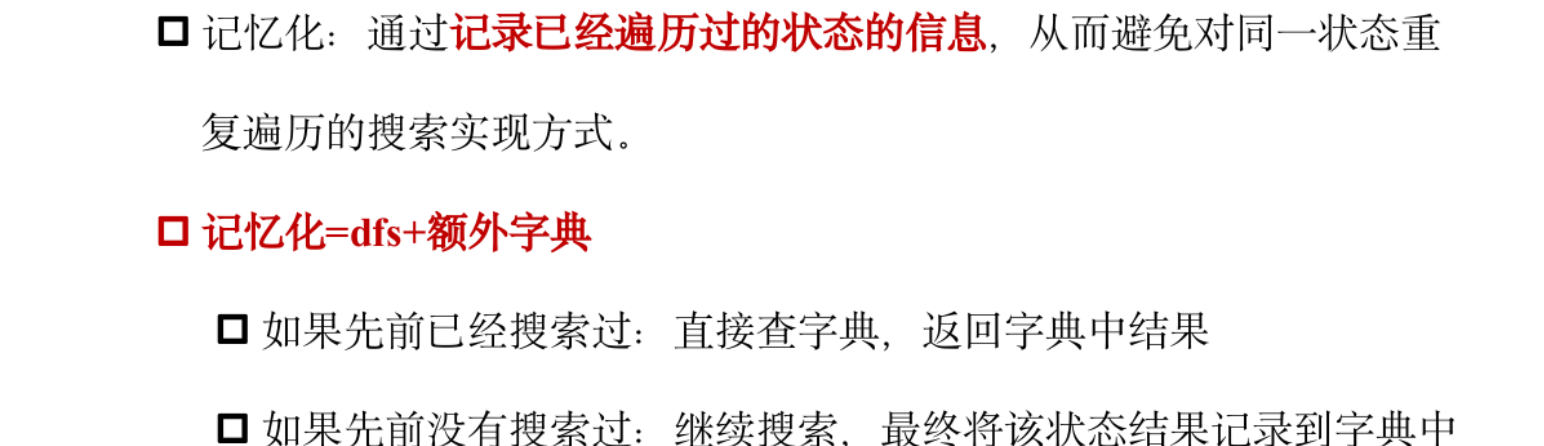
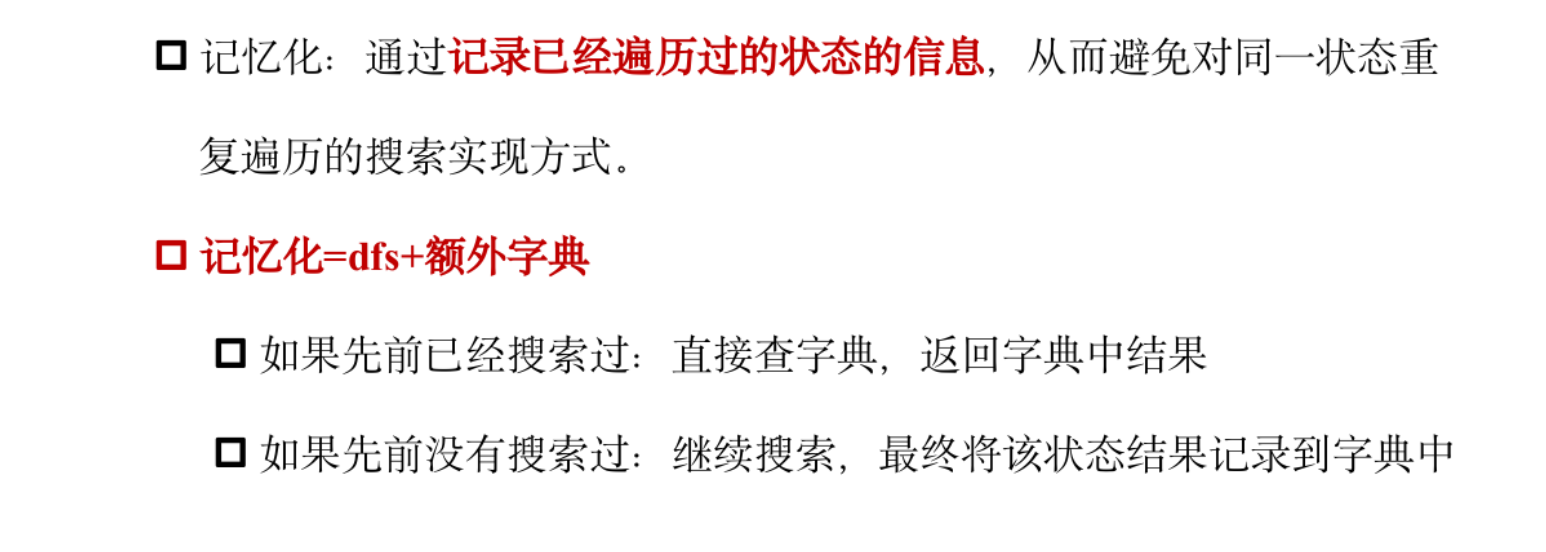
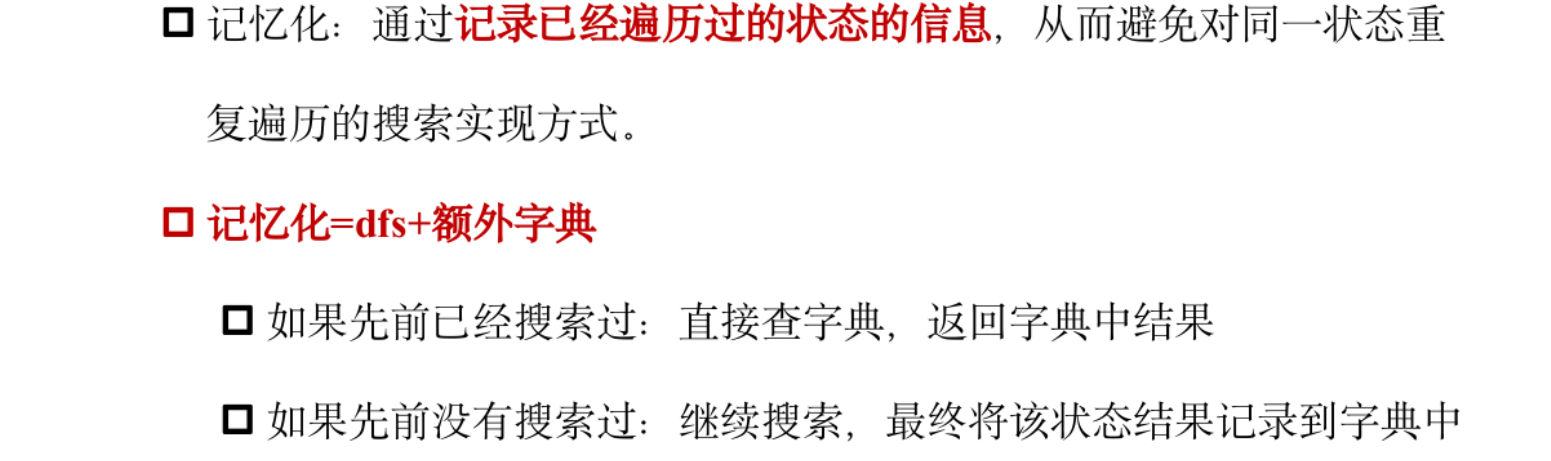

### 极速版斐波那契数列

In [10]:
from functools import lru_cache

@lru_cache(maxsize=None)
def f(x):
    if x==0 or x==1:
        return 1
    return f(x-1)+f(x-2)

n = int(input())
print(f(n))

20365011074


### lanqiao 3820 混境之地

小蓝有一天误入了一个混境之地。

好消息是：他误打误撞拿到了一张地图，并从中获取到以下信息：

混境之地是一个 $n*m$ 大小的矩阵，其中第 $i$ 行第 $j$ 列的的点 $h_{ij}$ 表示第 $i$ 行第 $j$ 列的高度。
他现在所在位置的坐标为 $(A,B)$ ，而这个混境之地出口的坐标为 $(C,D)$ ，当站在出口时即表示可以逃离混境之地。
小蓝有一个喷气背包，使用时，可以原地升高 $k$ 个单位高度。坏消息是：由于小蓝的体力透支，所以只可以往低于当前高度的方向走。喷漆背包燃料不足，只可以最后使用一次。小蓝可以往上下左右四个方向行走，不消耗能量。

小蓝想知道他能否逃离这个混境之地，如果可以逃离这里，输入 Yes ，反之输出 No 。

#### 输入格式

第 1 行输入三个正整数 n,m,k。n,m 表示混境之地的大小，k 表示使用一次喷气背包可以升高的高度。

第 2 行输入四个正整数 A,B,C,D ，表示小蓝当前所在位置的坐标，以及混境之地出口的坐标。

第 3 行至第 n+2 行，每行 m 个整数，表示混境之地不同位置的高度。

#### 输出格式

输出数据共一行一个字符串：

若小蓝可以逃离混境之地，则输出 Yes 。
若小蓝无法逃离混境之地，则输出 No 。

#### 样例输入1

```text
5 5 30
1 1 5 5
3 20 13 12 11
19 17 33 72 10
12 23 12 23 9
21 43 23 12 2
21 34 23 12 1
```

#### 样例输出1

Yes

#### 样例解释1

从(1,1) 到 (5,5) 的一条可行道路为：(1,1) 处使用喷气背包。

(1,1)−>(1,2)−>(1,3)−>(1,4)−>(1,5)−>(2,5)−>(3,5)−>(4,5)−>(5,5) 。

#### 样例输入2

```text
5 5 10
1 1 5 5
3 2 13 12 11
1 17 33 72 10
12 23 12 23 9
21 43 23 12 2
21 34 23 12 1
```

#### 样例输出2

No

#### 样例解释2

可以证明不存在一条路径可以从起点到达终点。

In [ ]:
from functools import lru_cache

# lru_cache要求：传给 dfs 的参数必须是不可变类型（int/bool/set，不能传 list），
# 所以地图 Map 是全局变量，不进参数。
@lru_cache(maxsize=None)
def dfs(x, y, z):
    # print(x, y, z)
    #当前处于(x,y), z表示是否使用喷气背包
    #如果能逃离, 返回True, 否则返回False
    if x == C - 1 and y == D - 1:
        return True

    for i in range(4):
        xx, yy = x + dir[i][0], y + dir[i][1]
        if xx < 0 or xx >= n or yy < 0 or yy >= m:
            continue
        if Map[xx][yy] < Map[x][y]:
            if dfs(xx, yy, z):
                return True
        elif Map[xx][yy] < Map[x][y] + k and z == False:
            if dfs(xx, yy, True):
                return True
    return False

#四个方向
dir = [(1,0),(0,1),(-1,0),(0,-1)]
n, m, k = map(int, input().split())
A, B, C, D = map(int, input().split())
Map = []
for i in range(n):
    Map.append(list(map(int, input().split())))

if dfs(A - 1, B - 1, False):
    print("Yes")
else:
    print("No")

### lanqiao 216 地宫取宝

X 国王有一个地宫宝库。是 $n×m$ 个格子的矩阵。每个格子放一件宝贝。每个宝贝贴着价值标签。地宫的入口在左上角，出口在右下角。小明被带到地宫的入口，国王要求他只能向右或向下行走。走过某个格子时，如果那个格子中的宝贝价值比小明手中任意宝贝价值都大，小明就可以拿起它（当然，也可以不拿）。当小明走到出口时，如果他手中的宝贝恰好是 k 件，则这些宝贝就可以送给小明。

请你帮小明算一算，在给定的局面下，他有多少种不同的行动方案能获得这 k 件宝贝。

#### 输入描述
输入一行 3 个整数，用空格分开：$n,m,k (1≤n,m≤50,1≤k≤12)$。

接下来有 n 行数据，每行有 m 个整数 $C_i (0≤C_i≤12)$ 代表这个格子上的宝物的价值。

输出描述
要求输出一个整数，表示正好取 k 个宝贝的行动方案数。该数字可能很大，输出它对 10^9+7 取模的结果。

#### 输入输出样例

输入

```text
2 2 2
1 2
2 1
```

输出

2

## 【四】 进阶版/练习题

### P1036 [NOIP 2002 普及组] 选数

#### 题目描述

已知 $n$ 个整数 $x_1,x_2,\cdots,x_n$，以及 $1$ 个整数 $k$（$k<n$）。从 $n$ 个整数中任选 $k$ 个整数相加，可分别得到一系列的和。例如当 $n=4$，$k=3$，$4$ 个整数分别为 $3,7,12,19$ 时，可得全部的组合与它们的和为：

$3+7+12=22$

$3+7+19=29$

$7+12+19=38$

$3+12+19=34$

现在，要求你计算出和为素数共有多少种。

例如上例，只有一种的和为素数：$3+7+19=29$。

#### 输入格式

第一行两个空格隔开的整数 $n,k$（$1 \le n \le 20$，$k<n$）。

第二行 $n$ 个整数，分别为 $x_1,x_2,\cdots,x_n$（$1 \le x_i \le 5\times 10^6$）。

#### 输出格式

输出一个整数，表示种类数。

#### 输入输出样例 #1

#### 输入 #1

```
4 3
3 7 12 19

```

#### 输出 #1

```
1

```

### 说明/提示

**【题目来源】**

NOIP 2002 普及组第二题

In [ ]:
import math
from functools import lru_cache
@lru_cache(maxsize=None)
def isprime(x):
    if x<=1:
        return False
    for i in range(2,int(math.sqrt(x))+1):
        if x%i==0:
            return False
    return True
n,k = map(int,input().split())
a = list(map(int,input().split()))
vis = [0]*n
ans = 0
def dfs(start,count,current_sum):
    # 已经选了count个数字
    if count==k:
        global ans
        if isprime(current_sum):
            ans += 1
        return
    for i in range(start,n):
        dfs(i+1,count+1,current_sum+a[i])
dfs(0,0,0)
print(ans)


### P1019 [NOIP 2000 提高组] 单词接龙（疑似错题）

#### 题目背景

注意：本题为上古 NOIP 原题，不保证存在靠谱的做法能通过该数据范围下的所有数据。本题的难度仅代表设计算法可以通过本题原始数据的难度。

本题为搜索题，本题不接受 hack 数据。[关于此类题目的详细内容](https://www.luogu.com.cn/paste/pf94n89x)

NOIP2000 提高组 T3

#### 题目描述

单词接龙是一个与我们经常玩的成语接龙相类似的游戏，现在我们已知一组单词，且给定一个开头的字母，要求出以这个字母开头的最长的“龙”（每个单词都最多在“龙”中出现两次），在两个单词相连时，其重合部分合为一部分，例如 `beast` 和 `astonish`，如果接成一条龙则变为 `beastonish`，另外相邻的两部分不能存在包含关系，例如 `at` 和 `atide` 间不能相连。

#### 输入格式

输入的第一行为一个单独的整数 $n$ 表示单词数，以下 $n$ 行每行有一个单词，输入的最后一行为一个单个字符，表示“龙”开头的字母。你可以假定以此字母开头的“龙”一定存在。

#### 输出格式

只需输出以此字母开头的最长的“龙”的长度。

#### 输入输出样例 #1

#### 输入 #1

```
5
at
touch
cheat
choose
tact
a

```

#### 输出 #1

```
23

```

#### 说明/提示

样例解释：连成的“龙”为 `atoucheatactactouchoose`。

$n \le 20$。

In [ ]:
n = int(input())
words = []
for _ in range(n):
    words.append(input().strip())
ch = input().strip()
common = [[[] for _ in range(n)] for _ in range(n)]
# common[i][j] i的后缀和j的前缀
for i in range(n):
    for j in range(n):
        # 相等不是包含关系
        m = min(len(words[i]),len(words[j])) - 1
        for k in range(m,0,-1):
            if words[j][:k]==words[i][-k:]:
                common[i][j].append(k)
vis = [0]*n
ans = 0
def dfs(length,last):
    global ans
    ans = max(ans,length)
    for nxt in range(n):
        if vis[nxt]<2 and common[last][nxt]:
            for k in common[last][nxt]:
                vis[nxt] += 1
                dfs(length+len(words[nxt])-k,nxt)
                vis[nxt] -= 1
for i in range(n):
    if ch==words[i][0]:
        vis[i] = 1
        dfs(len(words[i]),i)
        vis[i] = 0
print(ans)

### P1101 单词方阵

#### 题目描述

给一 $n \times n$ 的字母方阵，内可能蕴含多个 `yizhong` 单词。单词在方阵中是沿着同一方向连续摆放的。摆放可沿着 $8$ 个方向的任一方向，同一单词摆放时不再改变方向，单词与单词之间可以交叉，因此有可能共用字母。输出时，将不是单词的字母用 `*` 代替，以突出显示单词。

#### 输入格式

第一行输入一个数 $n$。$(7 \le n \le 100)$。

第二行开始输入 $n \times n$ 的字母矩阵。

#### 输出格式

突出显示单词的 $n \times n$ 矩阵。

#### 输入输出样例 #1

#### 输入 #1

```
7
aaaaaaa
aaaaaaa
aaaaaaa
aaaaaaa
aaaaaaa
aaaaaaa
aaaaaaa

```

#### 输出 #1

```
*******
*******
*******
*******
*******
*******
*******

```

#### 输入输出样例 #2

#### 输入 #2

```
8
qyizhong
gydthkjy
nwidghji
orbzsfgz
hhgrhwth
zzzzzozo
iwdfrgng
yyyygggg
```

#### 输出 #2

```
*yizhong
gy******
n*i*****
o**z****
h***h***
z****o**
i*****n*
y******g
```

In [ ]:
n = int(input())
a = []
for _ in range(n):
    a.append(list(input()))
dir = [(-1,0),(-1,-1),(0,-1),(1,-1),(1,0),(1,1),(0,1),(-1,1)]
ans = [['*']*n for _ in range(n)]
std = "yizhong"
def dfs(d,num,x,y):
    # dir是8个方向里面选择一个
    # num是yizhong这7个字符里面的第几个
    if num==7:
        return
    if a[x][y] == std[num]:
        path.append((x,y))
        xx,yy = x+dir[d][0],y+dir[d][1]
        if 0<=xx<=n-1 and 0<=yy<=n-1:
            dfs(d,num+1,xx,yy)
# 先找到所有的y
y = []
for i in range(n):
    for j in range(n):
        if a[i][j] =='y':
            y.append((i,j))
for xi,yi in y:
    for i in range(8):
        path = []
        dfs(i,0,xi,yi)
        if len(path)==7:
            for i in range(7):
                xx,yy = path[i]
                ans[xx][yy] = std[i]
for s in ans:
    print(*s,sep="")


### P2036 [COCI 2008/2009 #2] PERKET

#### 题目描述

Perket 是一种流行的美食。为了做好 Perket，厨师必须谨慎选择食材，以在保持传统风味的同时尽可能获得最全面的味道。你有 $n$ 种可支配的配料。对于每一种配料，我们知道它们各自的酸度 $s$ 和苦度 $b$。当我们添加配料时，总的酸度为每一种配料的酸度总乘积；总的苦度为每一种配料的苦度的总和。

众所周知，美食应该做到口感适中，所以我们希望选取配料，以使得酸度和苦度的绝对差最小。

另外，我们必须添加至少一种配料，因为没有任何食物是只以水为配料的。

#### 输入格式

第一行一个整数 $n$，表示可供选用的食材种类数。

接下来 $n$ 行，每行 $2$ 个整数 $s_i$ 和 $b_i$，表示第 $i$ 种食材的酸度和苦度。

#### 输出格式

一行一个整数，表示可能的总酸度和总苦度的最小绝对差。

#### 输入输出样例 #1

#### 输入 #1

```
1
3 10
```

#### 输出 #1

```
7
```

#### 输入输出样例 #2

#### 输入 #2

```
2
3 8
5 8
```

#### 输出 #2

```
1
```

#### 输入输出样例 #3

#### 输入 #3

```
4
1 7
2 6
3 8
4 9
```

#### 输出 #3

```
1
```

#### 说明/提示

对于第三组样例，选择最后三种食材，此时的总酸度为 $2 \times 3 \times 4 = 24$，总苦度为 $6+8+9=23$，差值为 $1$。

#### 数据规模与约定
对于 $100\%$ 的数据，有 $1 \leq n \leq 10$，且将所有可用食材全部使用产生的总酸度和总苦度小于 $1 \times 10^9$。
#### 说明
- 本题满分 $70$ 分。
- 题目译自 [COCI2008-2009](https://hsin.hr/coci/archive/2008_2009/) [CONTEST #2](https://hsin.hr/coci/archive/2008_2009/contest2_tasks.pdf) PERKET，译者 @[mnesia](https://www.luogu.com.cn/user/115711)。

In [ ]:
n = int(input())
s,b = [],[]
for _ in range(n):
    ss,bb = map(int,input().split())
    s.append(ss)
    b.append(bb)
ans = 10**9
m1,m2 = 1,0
def dfs(x):
    global m1
    global m2
    # 如果已经到了n
    if x==n:
        global ans
        if m1!=1 or m2!=0:
            ans = min(abs(m1-m2),ans)
        return
    m1 *= s[x]
    m2 += b[x]
    dfs(x+1)
    m1 //= s[x]
    m2 -= b[x]
    dfs(x+1)
dfs(0)
print(ans)